In [1]:
from vmc_ising import (
    output_dir,
    get_config,
    get_lattice,
    default_config,
    get_network,
    get_system,
)
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch
from pathlib import Path
from collections.abc import Iterable
import jsonlines
import pandas as pd

Running dilated_nns_xors.py


In [2]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
    .assign(
        n_signs_updated=lambda df: df.groupby("task_id")["signs_updated"].transform(
            "cumsum"
        )
    )
)

/gpfs/home1/ishchurov/frustrations-eda/misc_utils.py:206: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(dataframes).reset_index(drop=True)


In [3]:
df.columns

Index(['config_n_samples', 'config_lr', 'config_batch_size',
       'config_weight_decay', 'config_max_iter', 'config_lattice', 'config_J2',
       'config_use_symmetries', 'config_spin_inversion',
       'config_eval_set_max_size', 'config_device', 'config_random_seed',
       'config_dilations', 'config_hidden_channels', 'config_warm_up_overlap',
       'config_sign_update_period', 'config_sign_reconstruction.method',
       'config_sign_reconstruction.number_sweeps', 'config_warm_up.sign_noise',
       'config_log_prob_fn', 'config_kernel_size', 'amplitude_overlap',
       '‖∇E‖₂', 'E_full_delta', 'ipr', 'step', 'E_variance', 'start_timestamp',
       'task_id', 'device', 'warm_up', 'sign_overlap', 'step_since_warm_up',
       'signs_updated', 'signs_updated_at', 'step_since_signs_updated',
       'config_sign_reconstruction.repetitions', 'overlap',
       'config_checkpoint_log_prob_fn_each', 'git_hash', 'n_signs_updated'],
      dtype='object')

In [9]:
df.query('task_id')[[x for x in df.columns if x.startswith("config_")]].drop('config_hidden_channels', axis=1).drop_duplicates()

,config_n_samples,config_lr,config_batch_size,config_weight_decay,config_max_iter,config_lattice,config_J2,config_use_symmetries,config_spin_inversion,config_eval_set_max_size,...,config_dilations,config_warm_up_overlap,config_sign_update_period,config_sign_reconstruction.method,config_sign_reconstruction.number_sweeps,config_warm_up.sign_noise,config_log_prob_fn,config_kernel_size,config_sign_reconstruction.repetitions,config_checkpoint_log_prob_fn_each
7,10000,0.001,10000,0,15000,kagome2x3,1,False,None,50000,...,None,0.8,10,annealing,100,0.0,invariant_cnn,2,NaN,NaN


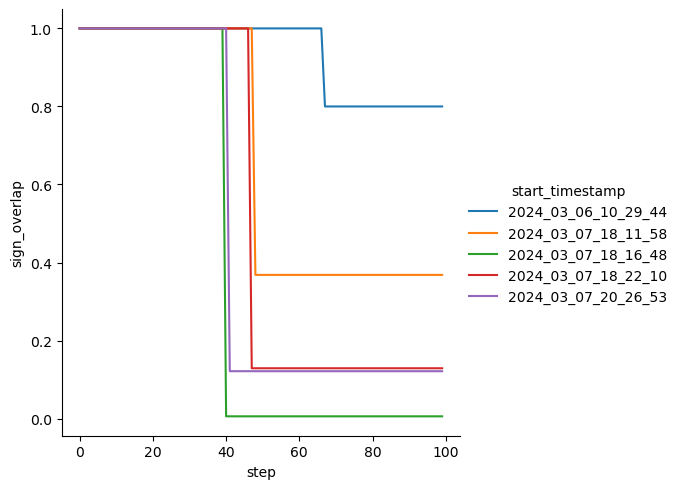

In [5]:
sns.relplot(
    df.query("task_id == 15 and step < 100"),
    x="step",
    y="sign_overlap",
    hue="start_timestamp",
    kind="line",
)

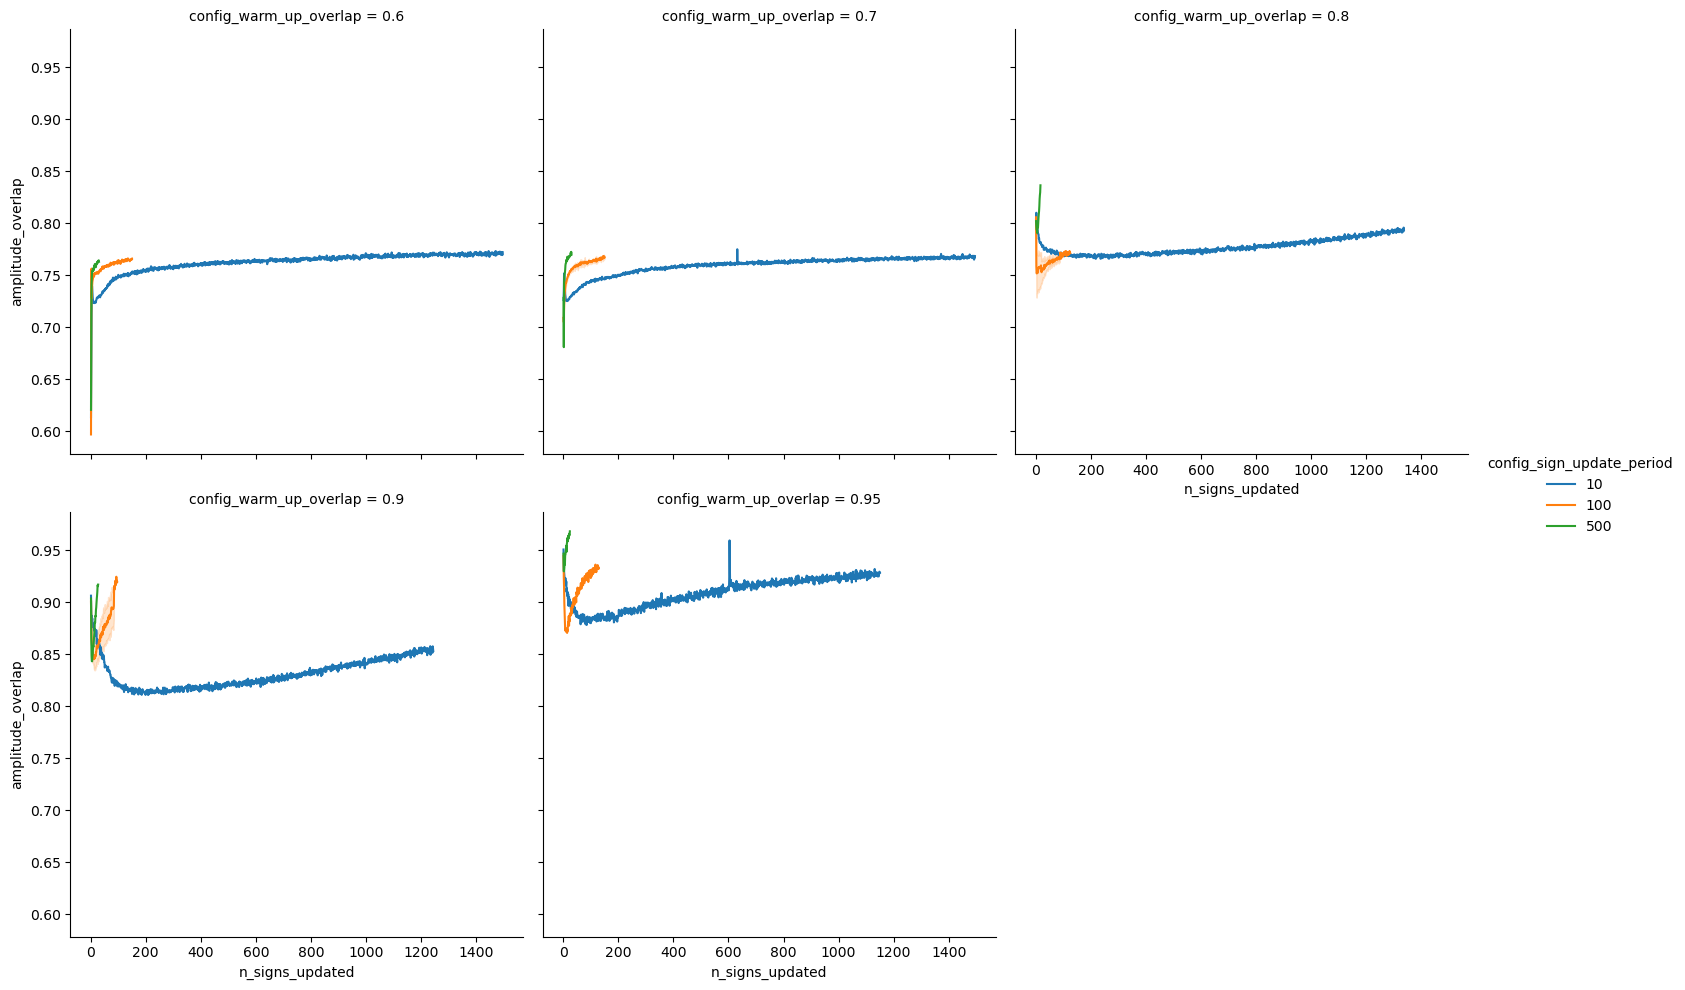

In [28]:
sns.relplot(
    df.query("task_id > 0 and signs_updated").pipe(
        column_to(str, "config_sign_update_period")
    ),
    x="n_signs_updated",
    y="amplitude_overlap",
    hue="config_sign_update_period",
    col="config_warm_up_overlap",
    kind="line",
    col_wrap=3,
)

0         0
1         0
2         0
3         0
4         0
         ..
281574    9
281575    9
281576    9
281577    9
281578    9
Name: signs_updated, Length: 281579, dtype: int64

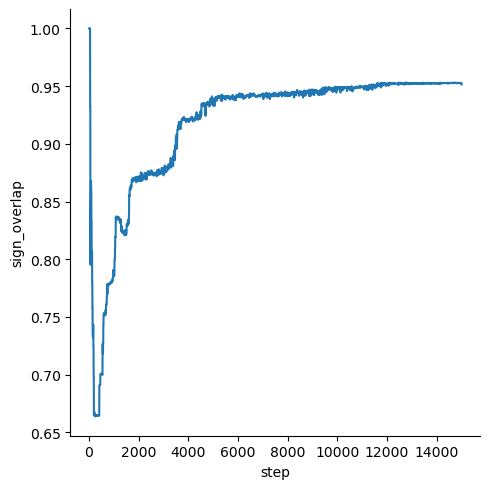

In [9]:
sns.relplot(df.query("task_id == 13"), x="step", y="sign_overlap", kind="line")

In [6]:
df.columns

Index(['config_n_samples', 'config_lr', 'config_batch_size',
       'config_weight_decay', 'config_max_iter', 'config_lattice', 'config_J2',
       'config_use_symmetries', 'config_spin_inversion',
       'config_eval_set_max_size', 'config_device', 'config_random_seed',
       'config_dilations', 'config_hidden_channels', 'config_warm_up_overlap',
       'config_sign_update_period', 'config_sign_reconstruction.method',
       'config_sign_reconstruction.number_sweeps', 'config_warm_up.sign_noise',
       'config_log_prob_fn', 'config_kernel_size', 'amplitude_overlap',
       '‖∇E‖₂', 'E_full_delta', 'ipr', 'step', 'E_variance', 'start_timestamp',
       'task_id', 'device', 'warm_up', 'sign_overlap', 'step_since_warm_up',
       'signs_updated', 'signs_updated_at', 'step_since_signs_updated',
       'overlap'],
      dtype='object')

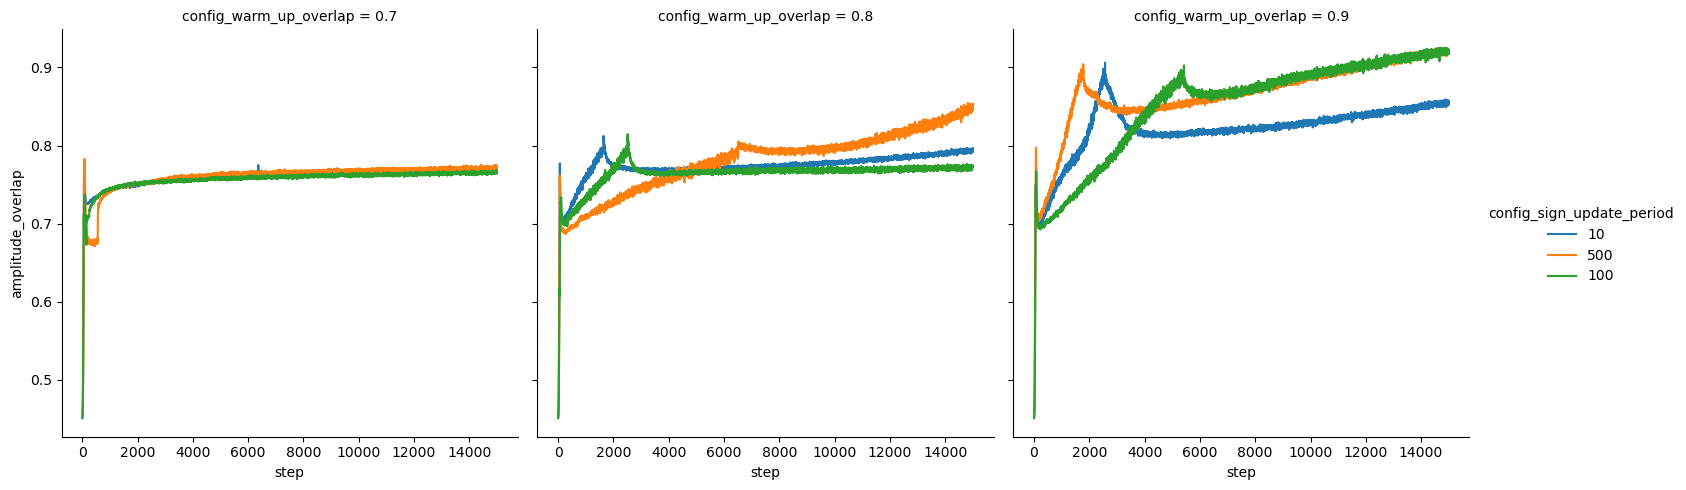

In [15]:
sns.relplot(
    df.query("task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7").pipe(
        column_to(str, "config_sign_update_period")
    ),
    x="step",
    y="amplitude_overlap",
    kind="line",
    hue="config_sign_update_period",
    col="config_warm_up_overlap",
    col_wrap=3,
)

In [20]:
df.query("task_id == 10").iloc[0]

config_n_samples                                          10000
config_lr                                                 0.001
config_batch_size                                         10000
config_weight_decay                                           0
config_max_iter                                           15000
config_lattice                                        kagome2x3
config_J2                                                     1
config_use_symmetries                                     False
config_spin_inversion                                      None
config_eval_set_max_size                                  50000
config_device                                              auto
config_random_seed                                         None
config_dilations                                           None
config_hidden_channels                             [32, 32, 32]
config_warm_up_overlap                                      0.7
config_sign_update_period               

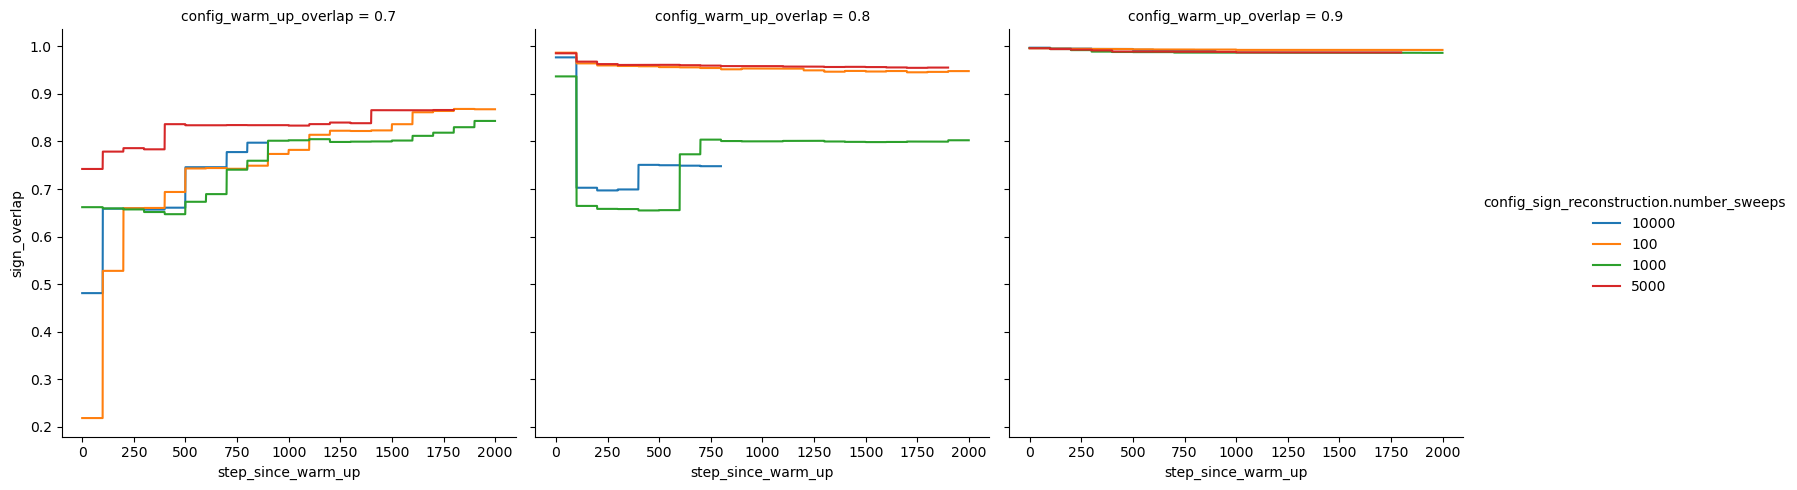

In [12]:
sns.relplot(
    df.query(
        "task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7 and config_sign_update_period == 100"
        "and step_since_warm_up < 2000"
    ).pipe(column_to(str, "config_sign_reconstruction.number_sweeps")),
    x="step_since_warm_up",
    y="sign_overlap",
    kind="line",
    col="config_warm_up_overlap",
    hue="config_sign_reconstruction.number_sweeps",
)

In [9]:
df.columns

Index(['config_n_samples', 'config_lr', 'config_batch_size',
       'config_weight_decay', 'config_max_iter', 'config_lattice', 'config_J2',
       'config_use_symmetries', 'config_spin_inversion',
       'config_eval_set_max_size', 'config_device', 'config_random_seed',
       'config_dilations', 'config_hidden_channels', 'config_warm_up_overlap',
       'config_sign_update_period', 'config_sign_reconstruction.method',
       'config_sign_reconstruction.number_sweeps', 'config_warm_up.sign_noise',
       'config_log_prob_fn', 'config_kernel_size', 'amplitude_overlap',
       '‖∇E‖₂', 'E_full_delta', 'ipr', 'step', 'E_variance', 'start_timestamp',
       'task_id', 'device', 'warm_up', 'sign_overlap', 'step_since_warm_up',
       'signs_updated', 'signs_updated_at', 'step_since_signs_updated',
       'config_sign_reconstruction.repetitions', 'overlap'],
      dtype='object')

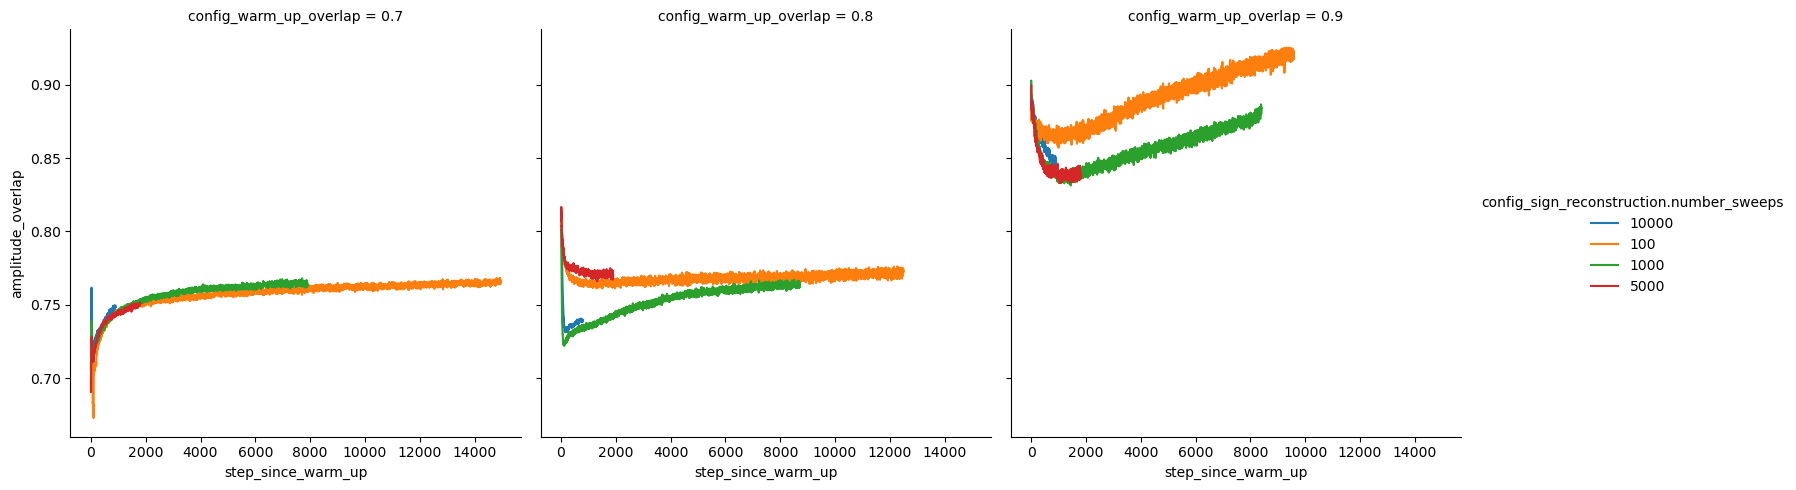

In [10]:
sns.relplot(
    df.query(
        "task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7 and config_sign_update_period == 100"
    ).pipe(column_to(str, "config_sign_reconstruction.number_sweeps")),
    x="step_since_warm_up",
    y="amplitude_overlap",
    kind="line",
    col="config_warm_up_overlap",
    hue="config_sign_reconstruction.number_sweeps",
)

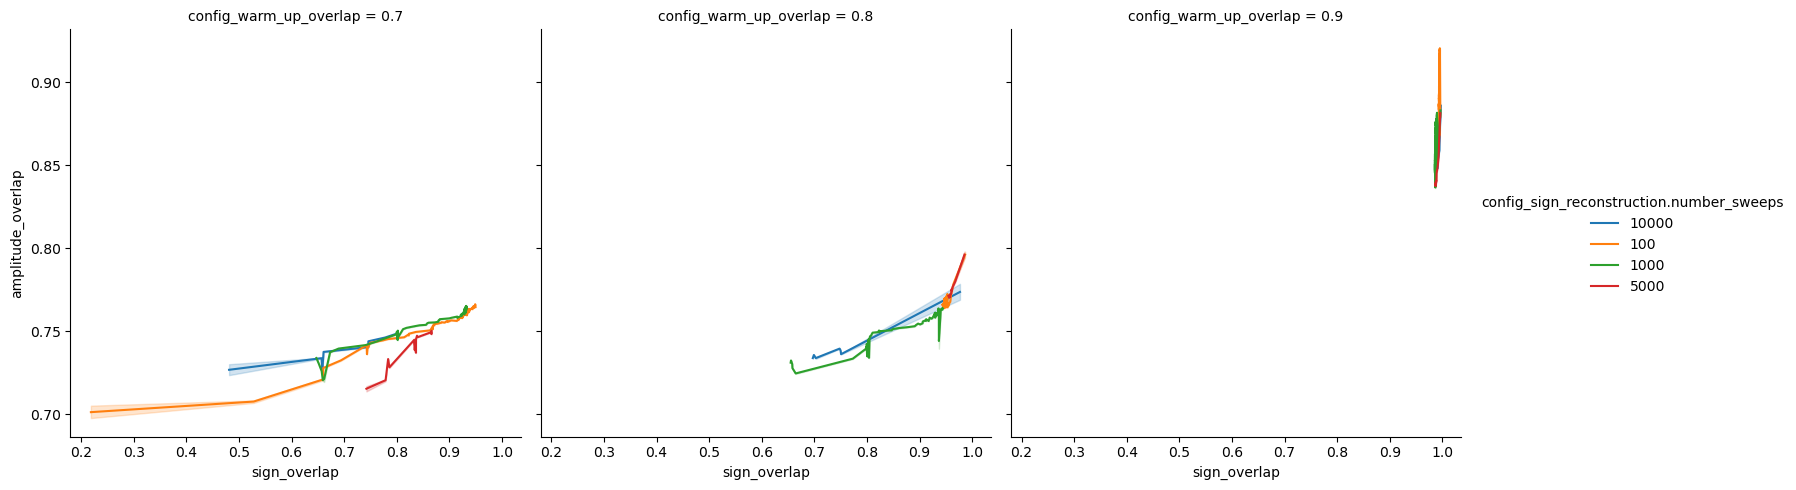

In [13]:
sns.relplot(
    df.query(
        "task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7 and config_sign_update_period == 100"
        "and not warm_up"
    ).pipe(column_to(str, "config_sign_reconstruction.number_sweeps")),
    x="sign_overlap",
    y="amplitude_overlap",
    kind="line",
    col="config_warm_up_overlap",
    hue="config_sign_reconstruction.number_sweeps",
)

In [5]:
config

{'n_samples': 10000,
 'lr': 0.001,
 'batch_size': 10000,
 'weight_decay': 0,
 'max_iter': 15000,
 'lattice': 'kagome2x3',
 'J2': 1,
 'use_symmetries': False,
 'spin_inversion': None,
 'eval_set_max_size': 50000,
 'device': 'auto',
 'random_seed': None,
 'dilations': None,
 'hidden_channels': None,
 'warm_up_overlap': 0.7,
 'sign_update_period': 100,
 'sign_reconstruction.method': 'annealing',
 'sign_reconstruction.number_sweeps': 100,
 'sign_reconstruction.repetitions': 16,
 'warm_up.sign_noise': 0.0,
 'checkpoint_log_prob_fn_each': 100}

In [18]:
config

{'n_samples': 10000,
 'lr': 0.001,
 'batch_size': 10000,
 'weight_decay': 0,
 'max_iter': 15000,
 'lattice': 'kagome2x3',
 'J2': 1,
 'use_symmetries': False,
 'spin_inversion': None,
 'eval_set_max_size': 50000,
 'device': 'auto',
 'random_seed': None,
 'dilations': None,
 'hidden_channels': None,
 'warm_up_overlap': 0.95,
 'sign_update_period': 10,
 'sign_reconstruction.method': 'annealing',
 'sign_reconstruction.number_sweeps': 100,
 'sign_reconstruction.repetitions': 16,
 'warm_up.sign_noise': 0.0,
 'checkpoint_log_prob_fn_each': None}

In [3]:
task_id = 25
config = get_config(task_id)
log_prob_fn = get_network(config, get_system(config))

2024-03-07 14:48:35.473 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=18
2024-03-07 14:48:35.474 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-03-07 14:48:35.475 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-03-07 14:48:35.475 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-03-07 14:48:35.495 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 48620


In [4]:
log_prob_fn.load_state_dict(
    torch.load(
        output_dir / f"{task_id}/log_prob_fn_{1000}.pt",
        map_location=torch.device("cpu"),
    )
)

<All keys matched successfully>

In [6]:
log_prob_fn(torch.tensor([1, 2, 3], dtype=torch.int64))

tensor([[ -7.9140],
        [ -7.2719],
        [-10.9693]], grad_fn=<AddmmBackward0>)

In [ ]:
2